## **Task 1 — Data Exploration with Pandas**

In [1]:
import pandas as pd

# Step 1: Load dataset
df = pd.read_csv("students.csv")

# Step 2: Print first 5 rows
print("First 5 rows:")
print(df.head())

# Step 3: Print shape and data types
print("\nShape (rows, columns):")
print(df.shape)

print("\nData Types:")
print(df.dtypes)

# Step 4: Summary statistics for numeric columns
print("\nSummary Statistics:")
print(df.describe())

# Step 5: Count of passed vs failed students
print("\nPass/Fail Count:")
print(df['passed'].value_counts())

# Step 6: Average score per subject for pass and fail
subject_cols = ['math', 'science', 'english', 'history', 'pe']

print("\nAverage scores for PASS students:")
print(df[df['passed'] == 1][subject_cols].mean())

print("\nAverage scores for FAIL students:")
print(df[df['passed'] == 0][subject_cols].mean())

# Step 7: Find student with highest overall average
df['avg_score'] = df[subject_cols].mean(axis=1)

top_student = df.loc[df['avg_score'].idxmax()]

print("\nTop Student (Highest Average):")
print(top_student)

First 5 rows:
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape (rows, columns):
(15, 9)

Data Types:
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary Statistics:
            math    scienc

## **Task 2 — Data Visualization with Matplotlib**

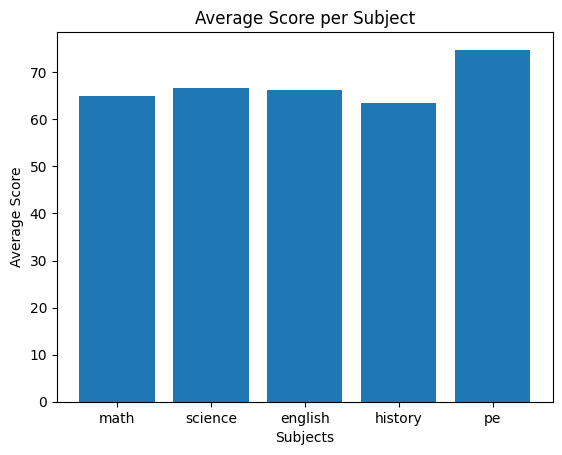

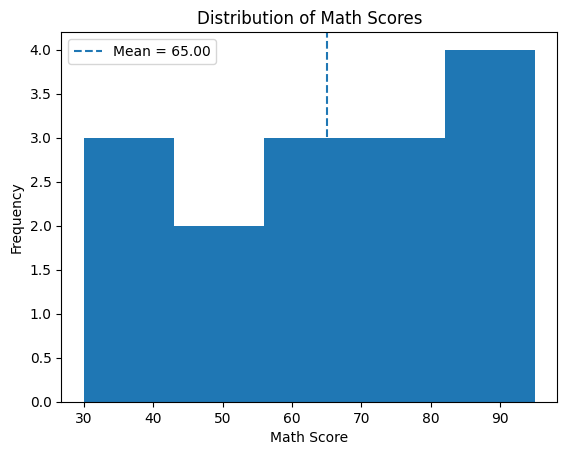

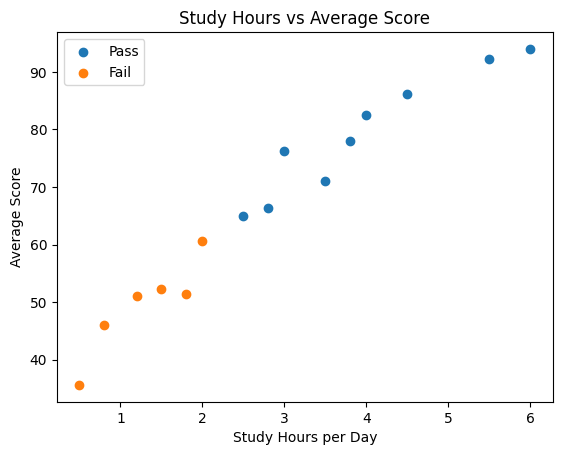

/tmp/ipykernel_1243/3509315328.py:68: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])    # Plot a boxplot comparing attendance of pass vs fail groups


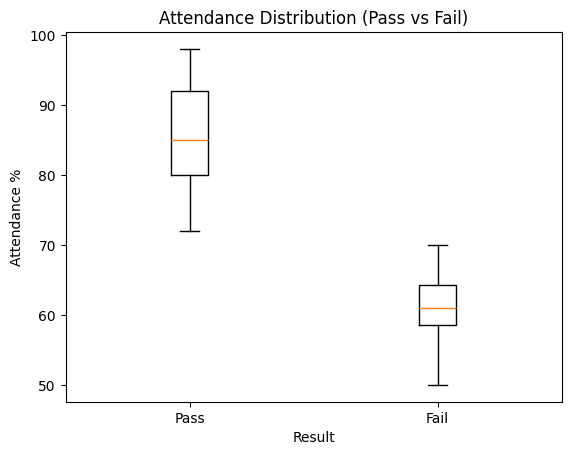

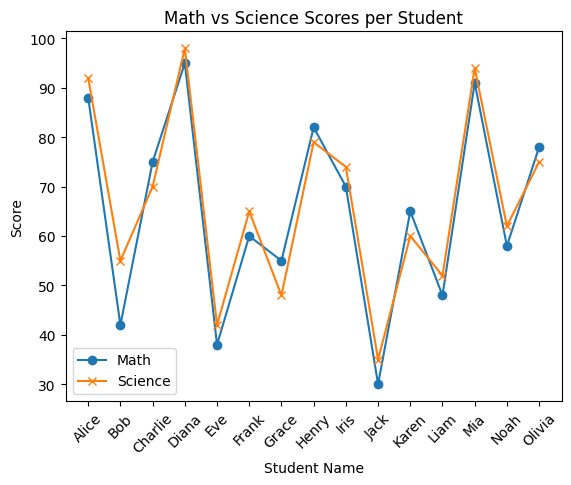

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load dataset
df = pd.read_csv("students.csv")

# Step 2: Create avg_score column
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)


# -------------------------------
# Plot 1: Bar Chart (Avg per subject)
# -------------------------------
avg_scores = df[subject_cols].mean()

plt.figure()                                        # Create a new figure for the bar chart
plt.bar(avg_scores.index, avg_scores.values)        # Plot a bar chart using subject names (index) and their average scores (values)
plt.title("Average Score per Subject")              # Add title and axis labels for clarity
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.savefig("plot1_bar.png")                        # Save the figure as an image file
plt.show()


# -------------------------------
# Plot 2: Histogram (Math scores)
# -------------------------------
plt.figure()
plt.hist(df['math'], bins=5)

mean_math = df['math'].mean()                           # Calculate the mean (average) of the math scores
plt.axvline(mean_math, linestyle='--', label=f"Mean = {mean_math:.2f}")   # Draw a vertical dashed line at the mean value

plt.title("Distribution of Math Scores")                # Add title and axis labels
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.legend()                                        # Show legend to explain the mean line
plt.savefig("plot2_hist.png")                     # Save the histogram as an image file
plt.show()


# -------------------------------
# Plot 3: Scatter Plot (Study vs Avg)
# -------------------------------
pass_df = df[df['passed'] == 1]
fail_df = df[df['passed'] == 0]

plt.figure()
plt.scatter(pass_df['study_hours_per_day'], pass_df['avg_score'], label="Pass")   # Plot scatter points for students who passed
plt.scatter(fail_df['study_hours_per_day'], fail_df['avg_score'], label="Fail")   # Plot scatter points for students who failed

plt.title("Study Hours vs Average Score")      # Add title and axis labels
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()                                  # Show legend to differentiate Pass vs Fail groups
plt.savefig("plot3_scatter.png")              # Save the scatter plot as an image file
plt.show()


# -------------------------------
# Plot 4: Box Plot (Attendance)
# -------------------------------
pass_attendance = pass_df['attendance_pct'].tolist()    # Convert attendance percentages for passed students into a list
fail_attendance = fail_df['attendance_pct'].tolist()    # Convert attendance percentages for failed students into a list

plt.figure()
plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])    # Plot a boxplot comparing attendance of pass vs fail groups

plt.title("Attendance Distribution (Pass vs Fail)")     # Add title and axis labels
plt.xlabel("Result")
plt.ylabel("Attendance %")
plt.savefig("plot4_box.png")              # Save the box plot as an image file
plt.show()


# -------------------------------
# Plot 5: Line Plot (Math & Science)
# -------------------------------
plt.figure()

plt.plot(df['name'], df['math'], marker='o', label="Math")          # Plot math scores for each student with 'o' markers
plt.plot(df['name'], df['science'], marker='x', label="Science")    # Plot Science scores for each student with 'x' markers

plt.title("Math vs Science Scores per Student")         # Add title and axis labels
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.xticks(rotation=45)                 # Rotate x-axis labels for better readability (useful if names are long)
plt.legend()                            # Show legend to distinguish between Math and Science lines
plt.savefig("plot5_line.png")           # Save the line plot as an image file
plt.show()

## **Task 3 — Data Visualization with Seaborn**

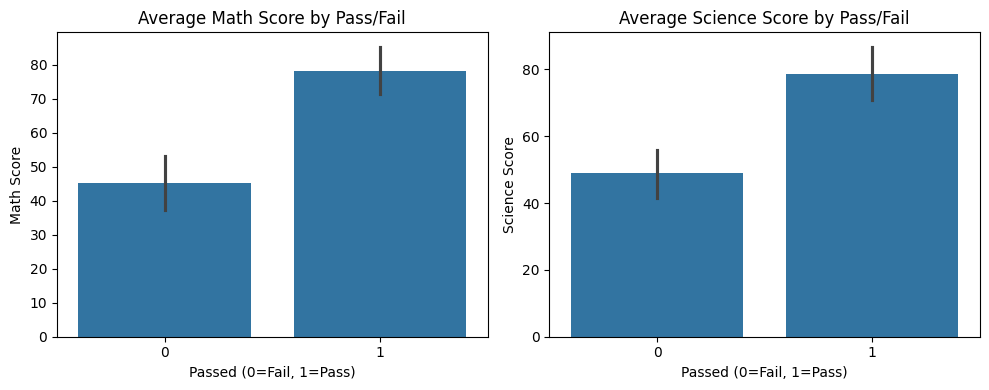

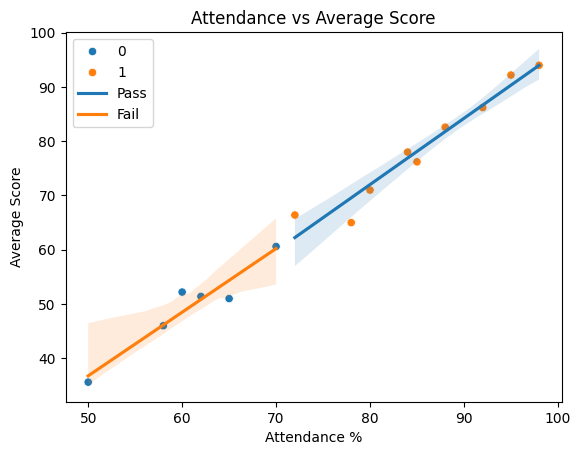

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("students.csv")

# Create avg_score column
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)


# -------------------------------
# Plot 1: Seaborn Bar Plots (Math & Science by Pass/Fail)
# -------------------------------
plt.figure(figsize=(10, 4))

# Subplot 1: Math
ax1 = plt.subplot(1, 2, 1)
sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Average Math Score by Pass/Fail")
ax1.set_xlabel("Passed (0=Fail, 1=Pass)")
ax1.set_ylabel("Math Score")

# Subplot 2: Science
ax2 = plt.subplot(1, 2, 2)
sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Average Science Score by Pass/Fail")
ax2.set_xlabel("Passed (0=Fail, 1=Pass)")
ax2.set_ylabel("Science Score")

plt.tight_layout()
plt.savefig("seaborn_barplots.png")
plt.show()


# -------------------------------
# Plot 2: Seaborn Scatter + Regression
# -------------------------------
plt.figure()

# Scatter plot with hue
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

# Regression lines for Pass and Fail
sns.regplot(data=df[df['passed'] == 1], x='attendance_pct', y='avg_score', scatter=False, label='Pass')
sns.regplot(data=df[df['passed'] == 0], x='attendance_pct', y='avg_score', scatter=False, label='Fail')

plt.title("Attendance vs Average Score")
plt.xlabel("Attendance %")
plt.ylabel("Average Score")
plt.legend()

plt.savefig("seaborn_scatter_reg.png")
plt.show()


# -------------------------------
# Comments (Comparison)
# -------------------------------
# Seaborn makes it easier to create statistical plots like bar plots with grouping and regression lines.
# It requires less manual work compared to Matplotlib for handling categories and aesthetics.
# However, Matplotlib provides more control and flexibility for fine-grained customization.

## **Task 4 — Machine Learning with scikit-learn**

X_train shape: (12, 7)
X_test shape : (3, 7)
Training Accuracy: 1.00
Test Accuracy: 1.00

--- Predictions ---
Jack | Actual: 0 | Predicted: 0 | ✅ correct
Liam | Actual: 0 | Predicted: 0 | ✅ correct
Alice | Actual: 1 | Predicted: 1 | ✅ correct

 Feature Importance (sorted by impact):
english                   : 0.8125
attendance_pct            : 0.5219
study_hours_per_day       : 0.4844
pe                        : 0.4750
math                      : 0.4379
science                   : 0.3230
history                   : 0.2629


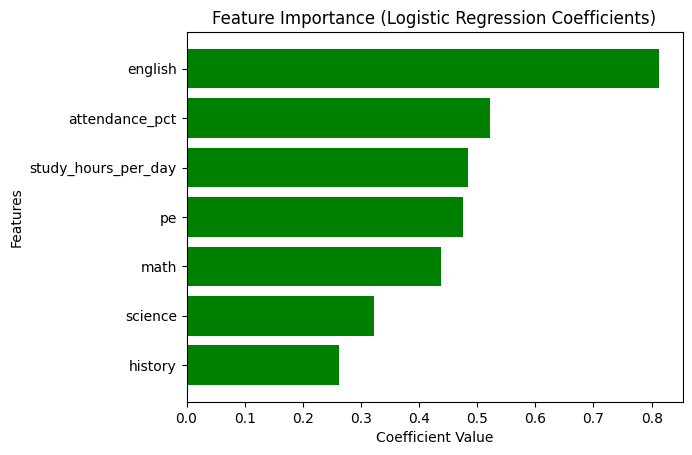


 Prediction: Pass
Probability (Fail): 0.09
Probability (Pass): 0.91


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Step 1: Load dataset
df = pd.read_csv("students.csv")
# Step 2: Define feature columns (exclude 'name' and target)
feature_cols = ['math', 'science', 'english', 'history', 'pe',
                'attendance_pct', 'study_hours_per_day']
# Step 3: Separate features (X) and target (y)
X = df[feature_cols]
y = df['passed']
# Step 4: Split into train and test sets (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Step 5: Scale features using StandardScaler
scaler = StandardScaler()
# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)
# Transform test data using same scaler
X_test_scaled = scaler.transform(X_test)
# Optional: print shapes to verify
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)


# Train a Model

from sklearn.linear_model import LogisticRegression
# Step 1: Create model
model = LogisticRegression()
# Step 2: Train model on scaled training data
model.fit(X_train_scaled, y_train)
# Step 3: Calculate training accuracy
train_accuracy = model.score(X_train_scaled, y_train)
# Step 4: Print result
print(f"Training Accuracy: {train_accuracy:.2f}")


# Evaluate the Model

# Step 1: Predict on test set
y_pred = model.predict(X_test_scaled)
# Step 2: Calculate test accuracy
from sklearn.metrics import accuracy_score
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_accuracy:.2f}")
# Step 3: Get student names using original index
test_names = df.loc[X_test.index, 'name']
print("\n--- Predictions ---")
# Step 4: Print results for each student
for name, actual, predicted in zip(test_names, y_test, y_pred):
    result = "✅ correct" if actual == predicted else "❌ wrong"
    print(f"{name} | Actual: {actual} | Predicted: {predicted} | {result}")


# Feature Importance

import matplotlib.pyplot as plt
# Step 1: Extract coefficients
coefficients = model.coef_[0]
# Step 2: Pair feature names with coefficients
feature_importance = list(zip(feature_cols, coefficients))
# Step 3: Sort by absolute value (largest first)
feature_importance_sorted = sorted(feature_importance, key=lambda x: abs(x[1]), reverse=True)
print("\n Feature Importance (sorted by impact):")
for feature, coef in feature_importance_sorted:
    print(f"{feature:25} : {coef:.4f}")
# Step 4: Prepare data for plotting
features = [f[0] for f in feature_importance_sorted]
values = [f[1] for f in feature_importance_sorted]
# Step 5: Assign colors (green = positive, red = negative)
colors = ['green' if v > 0 else 'red' for v in values]
# Step 6: Plot horizontal bar chart
plt.figure()
plt.barh(features, values, color=colors)
plt.title("Feature Importance (Logistic Regression Coefficients)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.gca().invert_yaxis()  # Highest importance on top
plt.savefig("feature_importance.png")
plt.show()



# Predict for a New Student

# Step 1: Define new student (same order as feature_cols)
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]
# Step 2: Scale using existing scaler
new_student_scaled = scaler.transform(new_student)
# Step 3: Predict class (0 = Fail, 1 = Pass)
prediction = model.predict(new_student_scaled)[0]
# Step 4: Predict probability
probabilities = model.predict_proba(new_student_scaled)[0]
# Step 5: Print results
result = "Pass" if prediction == 1 else "Fail"
print(f"\n Prediction: {result}")
print(f"Probability (Fail): {probabilities[0]:.2f}")
print(f"Probability (Pass): {probabilities[1]:.2f}")